In [1]:
# phase1_data_collection
import nfl_data_py as nfl
import os

seasons = list(range(2000, 2024))
os.makedirs('data', exist_ok=True)

schedules = nfl.import_schedules(seasons)
schedules = schedules[schedules['game_type'] == 'REG'][[
    'game_id', 'season', 'week', 'gameday',
    'home_team', 'away_team', 'home_score', 'away_score',
    'home_rest', 'away_rest', 'location', 'roof',
    'surface', 'temp', 'wind', 'div_game', 'total_line'
]]

pbp = nfl.import_pbp_data(seasons, columns=[
    'game_id', 'season', 'week',
    'home_team', 'away_team', 'posteam', 'defteam',
    'epa', 'home_score', 'away_score'
])
pbp = pbp[pbp['game_id'].isin(schedules['game_id'])]

schedules.to_parquet('data/raw_schedules.parquet', index=False)
pbp.to_parquet('data/raw_pbp.parquet', index=False)

2000 done.
2001 done.
2002 done.
2003 done.
2004 done.
2005 done.
2006 done.
2007 done.
2008 done.
2009 done.
2010 done.
2011 done.
2012 done.
2013 done.
2014 done.
2015 done.
2016 done.
2017 done.
2018 done.
2019 done.
2020 done.
2021 done.
2022 done.
2023 done.
Downcasting floats.


In [2]:
# phase2_data_cleaning
import pandas as pd
import numpy as np

pbp = pd.read_parquet('data/raw_pbp.parquet')
schedules = pd.read_parquet('data/raw_schedules.parquet')

schedules = schedules.dropna(subset=['home_score', 'away_score'])
schedules['total_points'] = schedules['home_score'] + schedules['away_score']
schedules['is_dome'] = schedules['roof'].isin(['dome', 'closed']).astype(int)

outdoor_median_temp = schedules.loc[schedules['is_dome'] == 0, 'temp'].median()
outdoor_median_wind = schedules.loc[schedules['is_dome'] == 0, 'wind'].median()
schedules['temp'] = schedules['temp'].fillna(schedules['is_dome'].map({1: 72, 0: outdoor_median_temp}))
schedules['wind'] = schedules['wind'].fillna(schedules['is_dome'].map({1: 0, 0: outdoor_median_wind}))

pbp = pbp[pbp['epa'].notna()]

schedules.to_parquet('data/clean_schedules.parquet', index=False)
pbp.to_parquet('data/clean_pbp.parquet', index=False)

In [3]:
# phase3_feature_engineering
import pandas as pd

pbp = pd.read_parquet('data/clean_pbp.parquet')
schedules = pd.read_parquet('data/clean_schedules.parquet')

off_epa = pbp.groupby(['game_id', 'posteam'])['epa'].mean().reset_index().rename(
    columns={'posteam': 'team', 'epa': 'off_epa'})
def_epa = pbp.groupby(['game_id', 'defteam'])['epa'].mean().reset_index().rename(
    columns={'defteam': 'team', 'epa': 'def_epa'})
game_epa = off_epa.merge(def_epa, on=['game_id', 'team'])

home = schedules[['game_id', 'season', 'week', 'home_team', 'home_rest']].rename(
    columns={'home_team': 'team', 'home_rest': 'rest_days'})
away = schedules[['game_id', 'season', 'week', 'away_team', 'away_rest']].rename(
    columns={'away_team': 'team', 'away_rest': 'rest_days'})
game_epa = game_epa.merge(pd.concat([home, away]).drop_duplicates(), on=['game_id', 'team'])
game_epa = game_epa.sort_values(['team', 'season', 'week']).reset_index(drop=True)

def rolling_prior(x, window=4):
    return x.shift(1).rolling(window, min_periods=1).mean()

for col in ['off_epa', 'def_epa']:
    game_epa[f'{col}_roll4'] = game_epa.groupby(['team', 'season'])[col].transform(
        lambda x: rolling_prior(x))
    game_epa[f'{col}_season'] = game_epa.groupby(['team', 'season'])[col].transform(
        lambda x: x.shift(1).expanding().mean())

home_feats = game_epa.merge(
    schedules[['game_id', 'home_team']].rename(columns={'home_team': 'team'}),
    on=['game_id', 'team']
).add_prefix('home_').rename(columns={'home_game_id': 'game_id'})

away_feats = game_epa.merge(
    schedules[['game_id', 'away_team']].rename(columns={'away_team': 'team'}),
    on=['game_id', 'team']
).add_prefix('away_').rename(columns={'away_game_id': 'game_id'})

features = schedules.merge(home_feats, on='game_id').merge(away_feats, on='game_id')
features = features[features['week'] > 3]

key_cols = [f'{side}_{col}' for side in ['home', 'away']
            for col in ['off_epa_roll4', 'def_epa_roll4', 'off_epa_season', 'def_epa_season']]
features = features.dropna(subset=key_cols)

features.to_parquet('data/features.parquet', index=False)

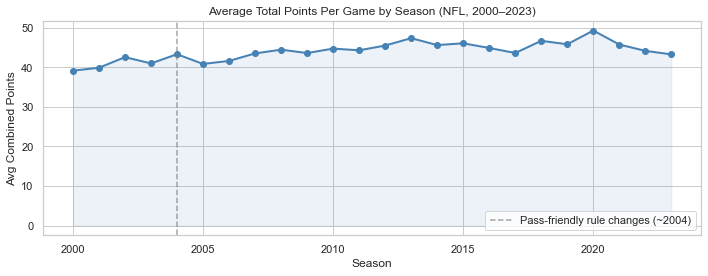

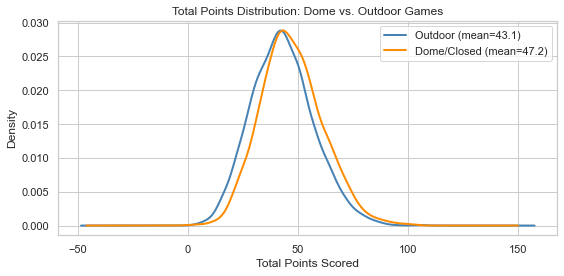

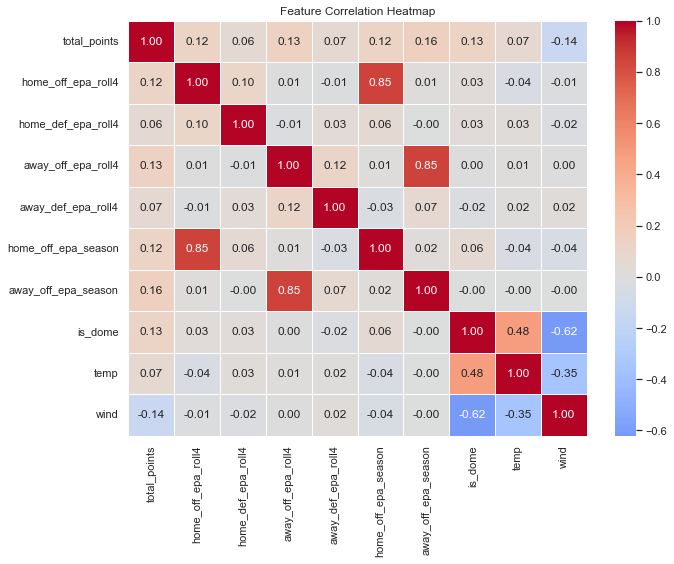

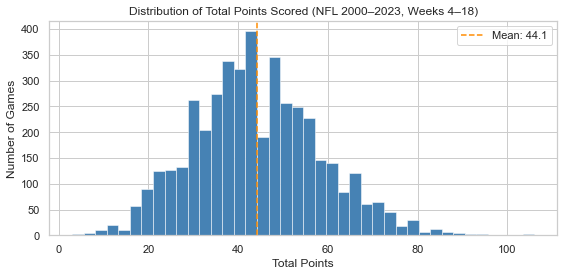

In [4]:
# phase4_eda
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

features = pd.read_parquet('data/features.parquet')
os.makedirs('figures', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')

season_avg = features.groupby('season')['total_points'].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(season_avg['season'], season_avg['total_points'], marker='o', linewidth=2, color='steelblue')
ax.axvline(2004, linestyle='--', color='gray', alpha=0.7, label='Pass-friendly rule changes (~2004)')
ax.fill_between(season_avg['season'], season_avg['total_points'], alpha=0.1, color='steelblue')
ax.set(title='Average Total Points Per Game by Season (NFL, 2000–2023)',
       xlabel='Season', ylabel='Avg Combined Points')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig1_scoring_trend.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
for dome, label, color in [(0, 'Outdoor', 'steelblue'), (1, 'Dome/Closed', 'darkorange')]:
    subset = features[features['is_dome'] == dome]['total_points']
    subset.plot.kde(ax=ax, label=f"{label} (mean={subset.mean():.1f})", color=color, linewidth=2)
ax.set(title='Total Points Distribution: Dome vs. Outdoor Games', xlabel='Total Points Scored')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig2_dome_vs_outdoor.png', dpi=150)
plt.show()

model_cols = [
    'total_points', 'home_off_epa_roll4', 'home_def_epa_roll4',
    'away_off_epa_roll4', 'away_def_epa_roll4', 'home_off_epa_season',
    'away_off_epa_season', 'is_dome', 'temp', 'wind'
]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(features[model_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('figures/fig3_correlation_heatmap.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(features['total_points'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(features['total_points'].mean(), color='darkorange', linestyle='--',
           label=f"Mean: {features['total_points'].mean():.1f}")
ax.set(title='Distribution of Total Points Scored (NFL 2000–2023, Weeks 4–18)',
       xlabel='Total Points', ylabel='Number of Games')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig4_points_distribution.png', dpi=150)
plt.show()

            Model  CV RMSE  Test RMSE  Test MAE
Linear Regression    13.87      13.41     10.57
 Ridge Regression    13.87      13.41     10.57
    Random Forest    13.95      13.60     10.67
Gradient Boosting    14.27      13.63     10.68

Vegas RMSE=13.18 MAE=10.32 (n=447)


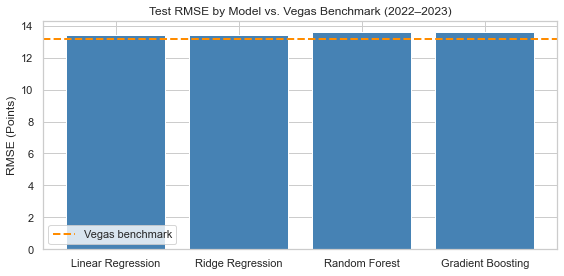

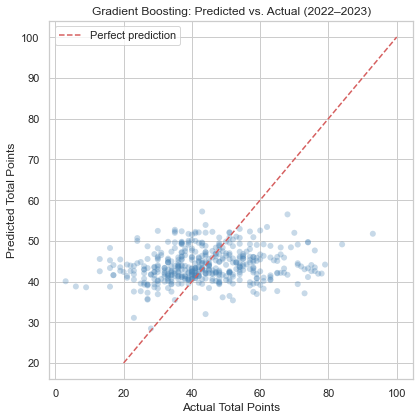

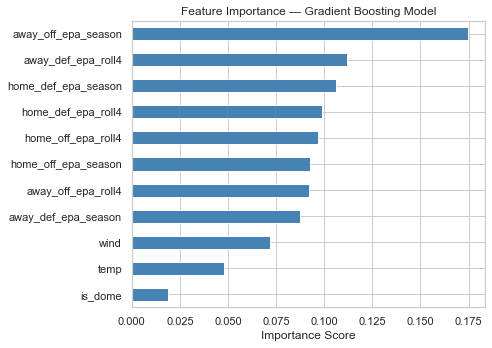

In [5]:
# phase5_modeling
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import joblib
import os

features = pd.read_parquet('data/features.parquet')
os.makedirs('models', exist_ok=True)

FEATURE_COLS = [
    'home_off_epa_roll4', 'home_def_epa_roll4',
    'home_off_epa_season', 'home_def_epa_season',
    'away_off_epa_roll4', 'away_def_epa_roll4',
    'away_off_epa_season', 'away_def_epa_season',
    'is_dome', 'temp', 'wind'
]

train = features[features['season'] <= 2021]
test  = features[features['season'] >= 2022]
X_train, y_train = train[FEATURE_COLS], train['total_points']
X_test,  y_test  = test[FEATURE_COLS],  test['total_points']

models = {
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge Regression':  Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
}

results = []
for name, model in models.items():
    cv_rmse = np.sqrt(-cross_val_score(model, X_train, y_train, scoring='neg_mean_squared_error', cv=5))
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({
        'Model': name,
        'CV RMSE': round(cv_rmse.mean(), 2),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_test, preds)), 2),
        'Test MAE': round(mean_absolute_error(y_test, preds), 2)
    })
    joblib.dump(model, f"models/{name.replace(' ', '_').lower()}.pkl")

results_df = pd.DataFrame(results)
results_df.to_csv('data/model_results.csv', index=False)
print(results_df.to_string(index=False))

test_vegas = test.dropna(subset=['total_line'])
print(f"\nVegas RMSE={np.sqrt(mean_squared_error(test_vegas['total_points'], test_vegas['total_line'])):.2f} "
      f"MAE={mean_absolute_error(test_vegas['total_points'], test_vegas['total_line']):.2f} "
      f"(n={len(test_vegas):,})")

best_model = joblib.load('models/gradient_boosting.pkl')
preds = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(results_df['Model'], results_df['Test RMSE'], color='steelblue', edgecolor='white')
ax.axhline(y=np.sqrt(mean_squared_error(test_vegas['total_points'], test_vegas['total_line'])),
           linestyle='--', color='darkorange', linewidth=2, label='Vegas benchmark')
ax.set(title='Test RMSE by Model vs. Vegas Benchmark (2022–2023)',
       ylabel='RMSE (Points)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig5_model_rmse.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, preds, alpha=0.3, color='steelblue', edgecolors='none')
ax.plot([20, 100], [20, 100], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set(title='Gradient Boosting: Predicted vs. Actual (2022–2023)',
       xlabel='Actual Total Points', ylabel='Predicted Total Points')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig6_predicted_vs_actual.png', dpi=150)
plt.show()

importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 5))
importances.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set(title='Feature Importance — Gradient Boosting Model', xlabel='Importance Score')
plt.tight_layout()
plt.savefig('figures/fig7_feature_importance.png', dpi=150)
plt.show()